## Implementing the idea of classification and why Linear regresssion fails here...

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button

In [2]:
x_train = np.array([0., 1, 2, 3, 4, 5])
y_train = np.array([0,  0, 0, 1, 1, 1])
x_train2 = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train2 = np.array([0, 0, 0, 1, 1, 1])

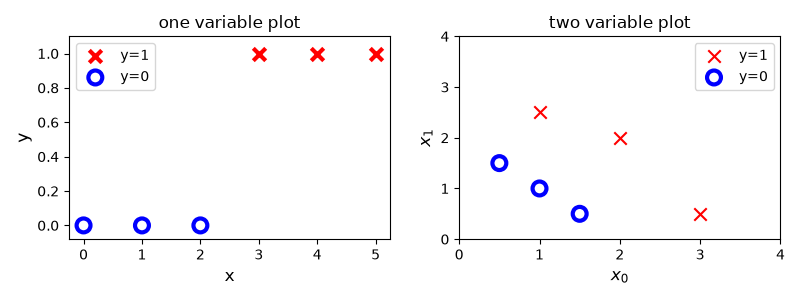

In [3]:
pos = y_train == 1
neg = y_train == 0

fig, ax = plt.subplots(1,2, figsize=(8, 3))
ax[0].scatter(x_train[pos], y_train[pos], marker='x', s=80, c='red',lw = 3, label='y=1')
ax[0].scatter(x_train[neg], y_train[neg], marker='o', s=100, facecolors='none', edgecolors='b', lw=3, label='y=0')

ax[0].set_ylim(-0.08, 1.1)
ax[0].set_xlabel('x', fontsize=12)
ax[0].set_ylabel('y', fontsize=12)
ax[0].set_title('one variable plot')
ax[0].legend()

x_0 = x_train2[:,0]
x_1 = x_train2[:,1]

ax[1].scatter(x_0[pos], x_1[pos], marker='x', s=80, c='red', label='y=1')
ax[1].scatter(x_0[neg], x_1[neg], marker='o', s=100, facecolors='none', edgecolors='b', lw=3, label='y=0')
ax[1].axis([0,4,0,4])
ax[1].set_xlabel('$x_0$', fontsize=12)
ax[1].set_ylabel('$x_1$', fontsize=12)
ax[1].set_title('two variable plot')
ax[1].legend()
plt.tight_layout()
plt.show()


### Elucidating why linear regression fails in classification...


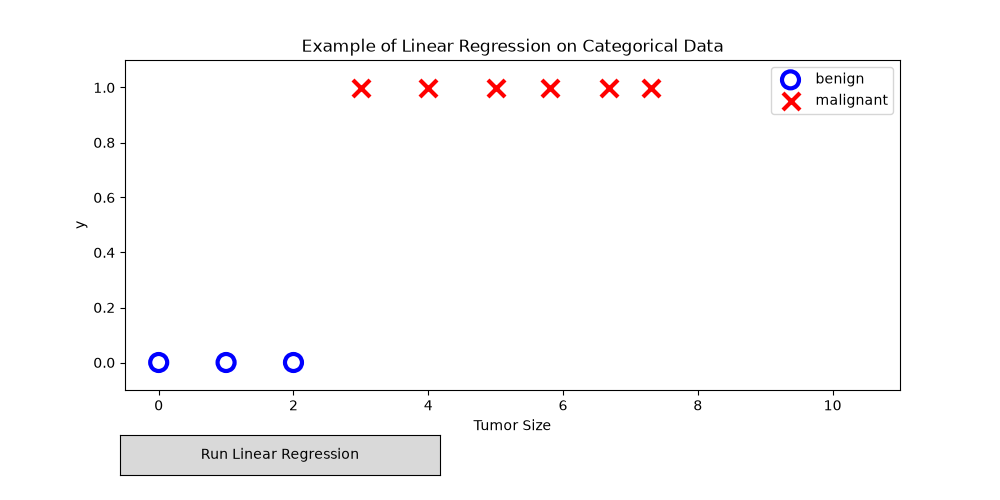

In [5]:
w = None
b = None

def linear_regression(x, y):
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    w = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)

    b = y_mean - w * x_mean

    return w, b

fig, ax = plt.subplots(figsize=(10, 5))
plt.subplots_adjust(bottom=0.22)

ax.set_xlim(-0.5, 11)
ax.set_ylim(-0.1, 1.1)

ax.set_xlabel("Tumor Size")
ax.set_ylabel("y")
ax.set_title("Example of Linear Regression on Categorical Data")

def draw_points():
    benign = y_train == 0
    malignant = y_train == 1

    ax.scatter(x_train[benign], y_train[benign], marker='o', facecolors='none', edgecolors='blue', s = 150, lw=3, label='benign')
    ax.scatter(x_train[malignant], y_train[malignant], marker='x', color='red', s=150, lw=3, label='malignant')

def draw_regression():
    global w, b 

    w, b = linear_regression(x_train, y_train)

    x_line = np.linspace(-0.5, 11, 200)
    y_line = w*x_line + b

    ax.plot(x_line, y_line, lw=3, label=f"y = {w:.2f}x + ({b:.2f})")

    threshold_x = (0.5 - b) / w

    ax.axvline(threshold_x, linestyle='--', lw=2, label=f"0.5 threshold = {threshold_x:.2f}")
    print(f"w = {w:.4f}")
    print(f"b = {b:.4f}")
    print(f"threshold = {threshold_x:.4f}")

def onclick(event):
    global x_train, y_train

    if event.inaxes != ax:
        return

    if event.xdata is None or event.ydata is None:
        return

    x_new = event.xdata
    y_new = event.ydata

    if y_new >= 0.5:
        y_new = 1
    else:
        y_new = 0

    x_train = np.append(x_train, x_new)
    y_train = np.append(y_train, y_new)

    ax.clear()
    ax.set_xlim(-0.5, 11)
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlabel("Tumor Size")
    ax.set_ylabel("y")
    ax.set_title("Example of Linear Regression on Categorical Data")

    draw_points()
    ax.legend()
    fig.canvas.draw_idle()

button_ax = plt.axes([0.12, 0.05, 0.32, 0.08])

run_button = Button(button_ax, "Run Linear Regression")
def run_regression(event):
    ax.clear()
    ax.set_xlim(-0.5, 11)
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlabel("Tumor Size")
    ax.set_ylabel("y")
    ax.set_title("Example of Linear Regression on Categorical Data")

    draw_points()
    draw_regression()
    ax.legend()
    fig.canvas.draw_idle()
run_button.on_clicked(run_regression)

fig.canvas.mpl_connect('button_press_event', onclick)

draw_points()
ax.legend()
plt.show()